# [LAB13] 딥러닝 > 비정형 데이터 > 3. CNN | Fashion Mnist

## #01. 준비작업

### [1] 패키지 가져오기

In [1]:
import os
import numpy as np
import seaborn as sb

from pandas import DataFrame, read_csv
from matplotlib import pyplot as plt
from tqdm.keras import TqdmCallback
from datetime import datetime as dt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from keras_tuner import Hyperband

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.losses import mse
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import AUC
try:
    from tensorflow.keras.metrics import F1Score
except AttributeError:
    try:
        from tensorflow_addons.metrics import F1Score
    except ImportError:
        F1Score = None  # TF 2.16 미만: pip install tensorflow-addons 또는 F1 제외

# CNN 모델 구축을 위한 레이어와 최적화, 손실함수, 콜백, 성능평가 지표 등 필요한 기능들
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout, Activation, Conv2D, MaxPool2D, Flatten

# 텐서플로우 내장 데이터셋인 패션 MNIST 불러오기
from tensorflow.keras.datasets.fashion_mnist import load_data

: 

### [2] 데이터셋 준비하기

원본 이미지는 아래 URL에서 다운로드 가능

> https://www.kaggle.com/datasets/prashantdandriyal/mnistfashionpng
>
> https://data.hossam.kr/tensor/fashion_mnist_png.7z

여기서는 용량 문제로 인해 직접 다운로드 받지 않고 내장 데이터셋을 사용한다.

In [ ]:
(x_train, y_train), (x_test, y_test) = load_data()
print(f"훈련 데이터 {x_train.shape} 레이블 {y_train.shape}")
print(f"검증 데이터 {x_test.shape} 레이블 {y_test.shape}")

훈련 데이터 (60000, 28, 28) 레이블 (60000,)
검증 데이터 (10000, 28, 28) 레이블 (10000,)


#### (1) 임의의 이미지 출력하기

In [ ]:
for i in x_train[1]:
    for j in i:
        print("%03d" % j, end="")
    print()

000000000000000001000000000000041188103054048043087168133016000000000000000000000000
000000000001000000000049136219216228236255255255255217215254231160045000000000000000
000000000000000014176222224212203198196200215204202201201201209218224164000000000000
000000000000000188219200198202198199199201196198198200200200200201200225041000000000
000000000000051219199203203212238248250245249246247252248235207203203222140000000000
000000000000116226206204207204101075047073048050045051063113222202206220224000000000
000000000000200222209203215200000070098000103059068071049000219206214210250038000000
000000000000247218212210215214000254243139255174251255205000215217214208220095000000
000000000045226214214215224205000042035060016017012013070000189216212206212156000000
000000000164235214211220216201052071089094083078070076092087206207222213219208000000
000000000106187223237248211198252250248245248252253250252239201212225215193113000000
00000000000000001705415922219320819219720020020020020120319521016

#### (2) 종속변수 이름 정의

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

#### 데이터 그려보기

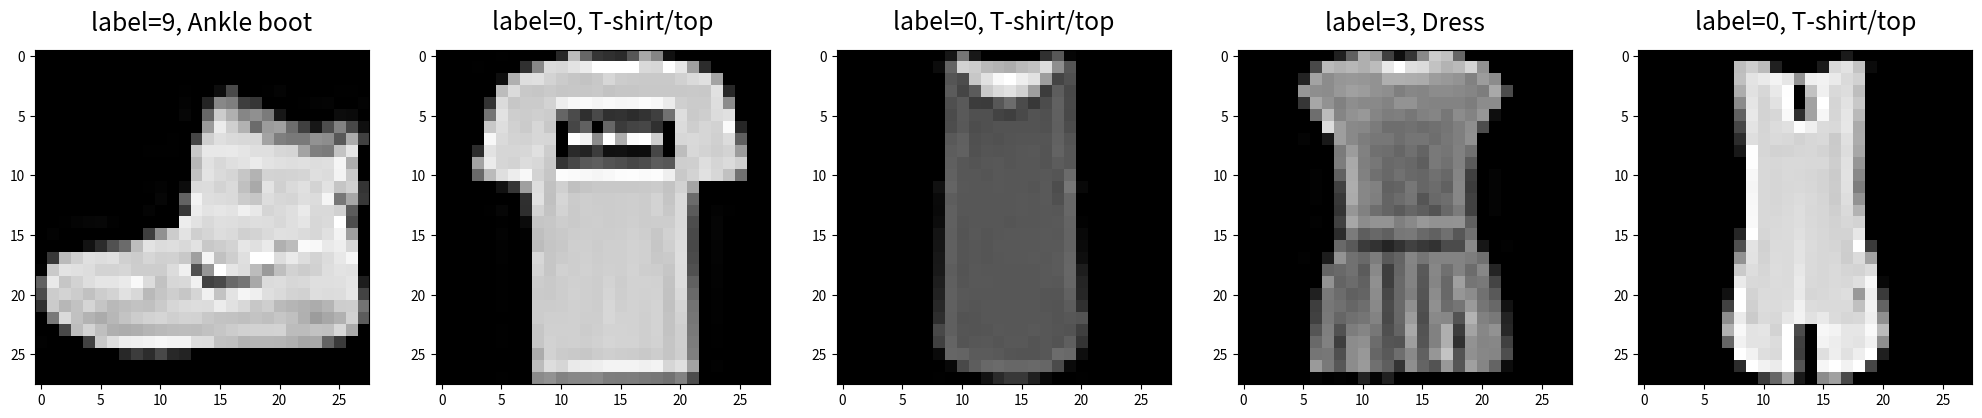

In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(25, 5), dpi=100)

for i in range(0, len(ax)):
    train = x_train[i]
    label = y_train[i]
    ax[i].imshow(train, cmap="gray")
    ax[i].set_title("label=%d, %s" % (label, class_names[label]))

## #02. 데이터 전처리

### [1] 종속변수에 대한 one-hot-encoding

훈련/검증 데이터가 이미 구분되어 있으므로 `train_test_split()`을 적용할 필요는 없다.

종속변수(label)가 각 이미지의 실제 숫자값으로 구성되어 있으므로 `one-hot-encoding`은 필요하다.

In [ ]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)
print(y_test_one_hot)

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### [2] 독립변수 전처리 - 훈련, 검증용 독립변수(이미지)의 차수 재설정

훈련 데이터의 shape가 (60000, 28, 28)라는 것은 가로 28, 세로 28 크기의 이미지가 60000장 이라는 의미.

즉, 28x28의 이차배열이 6만개가 존재하는 의미

즉, 60000개의 2차원 배열을 학습해야 하는 것 보다 60000개의 784(28*28)개의 원소를 갖는 1차원 배열을 학습하는 것이 학습 효율이 더 좋다.

#### (1) 훈련 데이터의 차수 확인

In [ ]:
x_train.shape

(60000, 28, 28)

#### (2) 차수 변경

In [ ]:
x_train_reshape = x_train.reshape(
    x_train.shape[0], x_train.shape[1], x_train.shape[2], 1
)
x_test_reshape = x_test.reshape(x_test.shape[0], x_test.shape[1], x_test.shape[2], 1)
print(f"훈련 데이터 {x_train_reshape.shape} / 검증 데이터 {x_test_reshape.shape}")

훈련 데이터 (60000, 28, 28, 1) / 검증 데이터 (10000, 28, 28, 1)


#### (3) 레이블에 대한 one-hot-encoding

In [ ]:
y_train_cate = to_categorical(y_train)
y_test_cate = to_categorical(y_test)
print(y_test_cate)

[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### [3] 이미지 데이터 정규화

이미지와 같이 복잡한 데이터의 경우 BatchNormalization층을 적용하여 텐서플로우 모델 구성시 표준화를 수행하는 학습층을 추가할 수 있다.

그 경우 독립변수 데이터를 직접 표준화 할 필요가 없다.

BatchNormalization은 입력 데이터를 정규화(normalize)하고, 이에 대해 활성화 함수를 적용하기 전에 스케일링(scale) 및 이동(shift)을 수행합니다. 이렇게 스케일링 및 이동된 데이터는 활성화 함수의 입력으로 사용된다.

따라서, BatchNormalization은 Activation 레이어 이전에 사용되어야 한다.

만약 BatchNormalization을 Activation 레이어 이후에 적용한다면, 정규화된 데이터가 활성화 함수에 대해 스케일링 및 이동되기 전에 활성화 함수의 입력으로 사용되기 때문에, BatchNormalization을 적용하는 의미가 퇴색되며, 오히려 모델 성능을 떨어뜨릴 수 있다.

## #03. 훈련 모델 적합

### [1] 하이퍼 파라미터 튜닝 함수

( `Conv2D 적용 [-> BatchNormalization층 적용] -> MaxPool2D 적용 [-> Dropout]` )의 과정을 n번 반복 -> Flatten 레이어 추가 -> Dense층 n개 추가

* **Conv2D 층**
    - 영상이나 이미지의 특징을 확인하기 위한 함수
    - `filters`: 필터(커널)의 개수
    - `kernel_size`: 필터의 크기
    - `strides`: 필터의 이동 간격
    - `padding`: valid(패딩 없음), same(인풋과 아웃풋이 같도록 패딩)
    - `activation`: 활성화 함수
    - `input_shape`: 첫 레이어에 인풋으로 들어오는 크기
* **BatchNormalization (배치정규화)**
    - 신경망 입력데이터를 평균 0, 분산 1로 정규화해서 학습이 잘 이루어지도록 하는 방법
    - BatchNormalization 층에서 정규화를 수행하므로 별도의 정규화를 적용할 필요가 없다.
    - 만약 이 층을 적용하지 않는다면 학습 전에 별도의 정규화를 수행하는 것이 좋다.
* **MaxPool2D**
    - 컨볼루션 레이어의 출력 이미지에서 주요값만 뽑아 크기가 작은 출력 영상을 만든다.
    - `pool_size`: 축소시킬 필터의 크기(비율)
    - `strides`: 필터의 이동 간격. 기본값으로 pool_size를 갖는다.
    - 일반적으로 strides는 pool_size와 동일하게 적용되므로 생략하는 편.

In [ ]:
def tf_build(hp) -> Sequential:
    model = Sequential()

    # ------------------------#
    # Conv2D
    model.add(
        Conv2D(
            filters=hp.Choice("filters", values=[16, 32, 64]),
            kernel_size=hp.Choice("kernel_size", values=[3, 4, 5]),
            strides=hp.Choice("strides", values=[1, 2]),
            padding="same",
            input_shape=(28,28,1)
        )
    )

    # 표준화
    model.add(BatchNormalization())

    # Activation
    model.add(Activation("relu"))

    # MaxPool
    model.add(
        MaxPool2D(
            pool_size=hp.Choice("pool_size", values=[2, 3])
        )
    )

    # Dropout
    model.add(
        Dropout(
            hp.Choice("dropout", values=[0.0,0.05,0.1,0.2])
        )
    )

    # ------------------------#

    model.add(Flatten())

    # Dense Layer 튜닝
    model.add(
        Dense(
            units=hp.Choice("dense_units", values=[64,128,256,512])
        )
    )

    model.add(BatchNormalization())
    model.add(Activation("relu"))

    # Output
    model.add(Dense(10))
    model.add(BatchNormalization())
    model.add(Activation("softmax"))

    # compile
    _metrics = ["accuracy", AUC(name="auc")]
    if F1Score is not None:
        _metrics.append(F1Score(name="f1_score", average="macro"))
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=_metrics,
    )

    return model

### [2] 학습하기

In [ ]:
tuner = Hyperband(
    hypermodel=tf_build,
    objective="accuracy",
    max_epochs=10,
    factor=3,
    seed=52,
    directory="tensor-tuning",
    project_name="fashion_mnist_%s" % dt.now().strftime("%Y%m%d%H%M%S"),
)

tuner

/Users/leekh/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### [3] 하이퍼파라미터 튜닝 수행

> 이전 소스코드와 동일

In [ ]:
%%time

tuner.search(
    x_train_reshape,
    y_train_cate,
    epochs=5,
    batch_size=32,
    validation_data=(x_test_reshape, y_test_cate)
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()

if not best_hps:
    raise ValueError("No best hyperparameters found.")

print(f"""best hyperparameters: {best_hps[0].values}""")

Trial 30 Complete [00h 02m 27s]
accuracy: 0.9451666474342346

Best accuracy So Far: 0.9729333519935608
Total elapsed time: 00h 25m 55s
best hyperparameters: {'filters': 32, 'kernel_size': 3, 'strides': 1, 'pool_size': 2, 'dropout': 0.05, 'dense_units': 512, 'tuner/epochs': 10, 'tuner/initial_epoch': 4, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}
CPU times: user 2h 5min 26s, sys: 1h 25min 18s, total: 3h 30min 44s
Wall time: 25min 55s


### [4] 최종 모형 도출

> 11강 소스코드와 동일

In [ ]:
%%time

model = tuner.hypermodel.build(best_hps[0])

result = model.fit(
    #---------------------------------------------------
    x_train_reshape,                        # 학습 데이터 입력
    y_train_cate,                           # 학습 데이터의 타겟값 (정답)
    #---------------------------------------------------
    epochs=500,                             # 전체 학습 데이터셋을 500회 반복하여 학습
    #---------------------------------------------------
    validation_data=(x_test_reshape, y_test_cate),   # 검증 데이터 설정
    #---------------------------------------------------
    verbose=0,                              # 학습 과정 출력 생략
    callbacks=[
        TqdmCallback(verbose=1),            # 학습 진행 상황을 tqdm 형태로 보여주는 콜백 추가

        # 조기 종료 콜백
        # 너무 일찍 조기종료하면 모델이 충분히 학습되지 않고 에러율이 높게 나올 수 있음
        EarlyStopping(monitor='val_loss', patience=5, min_delta=0.001),

        # 학습률 감소 콜백: 검증 손실(val_loss)이 10회 연속 개선되지 않으면 학습률을 0.5배로 감소
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0, verbose=1)
    ] 
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

CPU times: user 17min 20s, sys: 8min 40s, total: 26min 1s
Wall time: 2min 44s


## #04 성능평가

### [1] 성능평가 지표

In [ ]:
train_eval = model.evaluate(x_train_reshape, y_train_cate, verbose=0, return_dict=True)
test_eval = model.evaluate(x_test_reshape, y_test_cate, verbose=0, return_dict=True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, "Dataset", ["Train", "Test"])

# Gap 계산
for metric in ["loss", "accuracy", "auc", "f1_score"]:
    final_results[f"{metric}_gap"] = None
    final_results.loc[1, f"{metric}_gap"] = (
        final_results.loc[1, metric] - final_results.loc[0, metric]
    )

final_results

,Dataset,accuracy,auc,f1_score,loss,loss_gap,accuracy_gap,auc_gap,f1_score_gap
0,Train,0.989,1.000,0.989,0.043,None,None,None,None
1,Test,0.920,0.994,0.921,0.247,0.204,-0.068,-0.006,-0.068


### [2] 학습 과정 확인

In [ ]:
history_df = DataFrame(data=result.history)
history_df["epoch"] = history_df.index + 1

history_df.head()

,accuracy,auc,f1_score,loss,val_accuracy,val_auc,val_f1_score,val_loss,learning_rate,epoch
0,0.858,0.988,0.858,0.524,0.896,0.994,0.895,0.325,0.001,1
1,0.897,0.994,0.897,0.328,0.908,0.995,0.907,0.272,0.001,2
2,0.916,0.996,0.916,0.262,0.911,0.995,0.912,0.262,0.001,3
3,0.929,0.997,0.929,0.215,0.914,0.995,0.915,0.251,0.001,4
4,0.940,0.998,0.940,0.179,0.921,0.995,0.921,0.234,0.001,5


### [3] 학습 결과 시각화

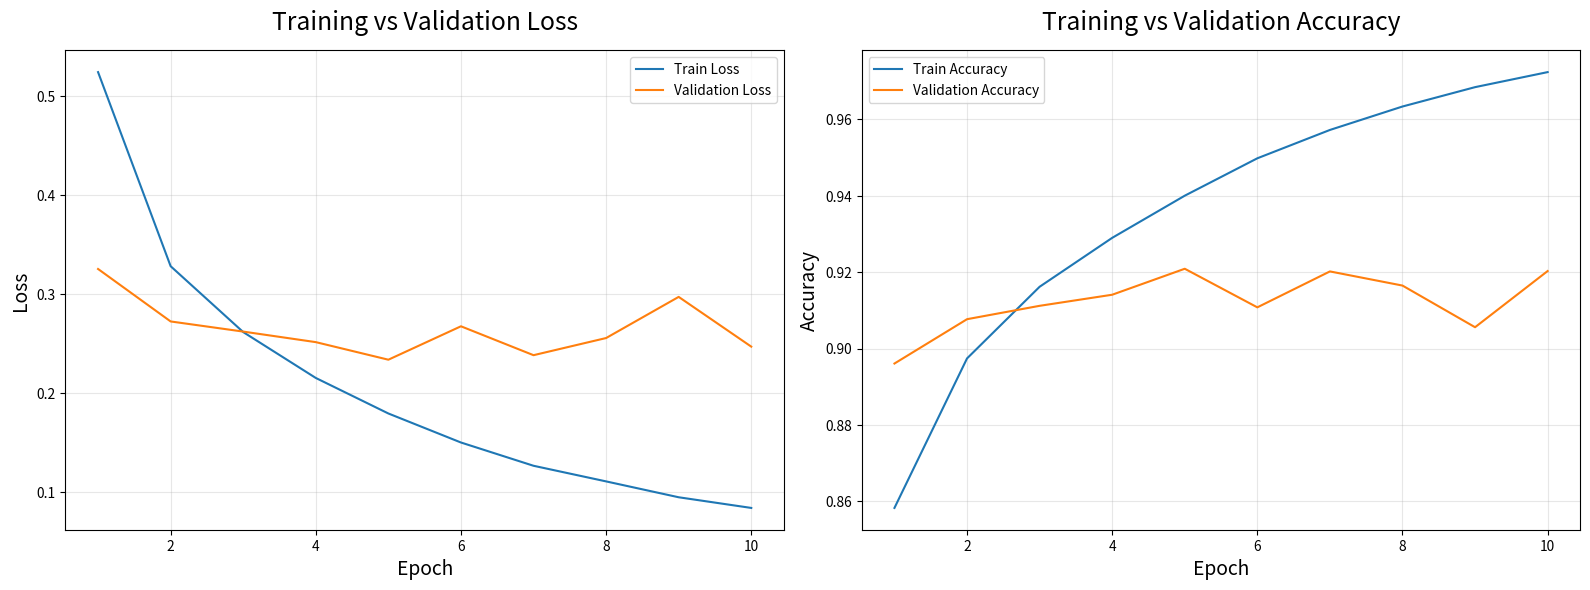

In [ ]:
figsize = (1600 / 100, 600 / 100)
fig, ax = plt.subplots(1, 2, figsize=figsize, dpi=100)
fig.subplots_adjust(wspace=0.2, hspace=0.2)

# 훈련데이터의 손실률
sb.lineplot(
    data=history_df,
    x="epoch",
    y="loss",   # <--- 평가지표 이름 명시
    ax=ax[0],
    label="Train Loss"
)

# 검증 데이터의 손실률
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_loss",   # <--- 평가지표 이름 명시
    ax=ax[0],
    label="Validation Loss"
)

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training vs Validation Loss")

ax[0].grid(True, alpha=0.3)

# 훈련데이터의 정확도
sb.lineplot(
    data=history_df,
    x="epoch",
    y="accuracy",   # <--- 평가지표 이름 명시
    ax=ax[1],
    label="Train Accuracy"
)

# 검증 데이터의 정확도
sb.lineplot(
    data=history_df,
    x="epoch",
    y="val_accuracy",   # <--- 평가지표 이름 명시
    ax=ax[1],
    label="Validation Accuracy"
)

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].set_title("Training vs Validation Accuracy")

ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

### [4] 분류결과 확인

#### 분류값 얻기

In [ ]:
pred =  model.predict(x_test_reshape, verbose=0)
pred[: 5]

array([[5.1952538e-04, 3.8573511e-05, 4.3303426e-04, 2.3905428e-03,
        3.1500411e-05, 1.6594256e-04, 1.2050981e-05, 2.3792083e-04,
        5.2470528e-05, 9.9611849e-01],
       [6.9130991e-05, 4.8608449e-06, 9.9896526e-01, 7.2470255e-04,
        7.0246239e-07, 1.7197730e-05, 3.9303145e-06, 1.2220263e-04,
        1.3648291e-05, 7.8307370e-05],
       [9.1861853e-07, 9.9929887e-01, 2.9601524e-06, 3.8789539e-04,
        4.2378574e-06, 3.0197657e-04, 3.4184782e-07, 1.8965327e-06,
        8.5069809e-07, 4.7659597e-08],
       [5.0459073e-07, 9.9944818e-01, 2.4064047e-06, 3.6153191e-04,
        1.8898530e-05, 1.2114238e-04, 2.3099701e-06, 4.3492179e-05,
        1.0927490e-06, 4.7487791e-07],
       [4.6814524e-02, 7.2521820e-05, 1.3094301e-03, 7.7706376e-05,
        5.8099488e-04, 1.1021366e-03, 9.4925529e-01, 1.6929922e-04,
        1.2470342e-05, 6.0562562e-04]], dtype=float32)

### [5] 가장 큰 확률 값의 인덱스를 별도 리스트로 추출

In [ ]:
pred_classes = np.argmax(pred, axis=1)
pred_classes[:5]

array([9, 2, 1, 1, 6])

### [6] 데이터 비교

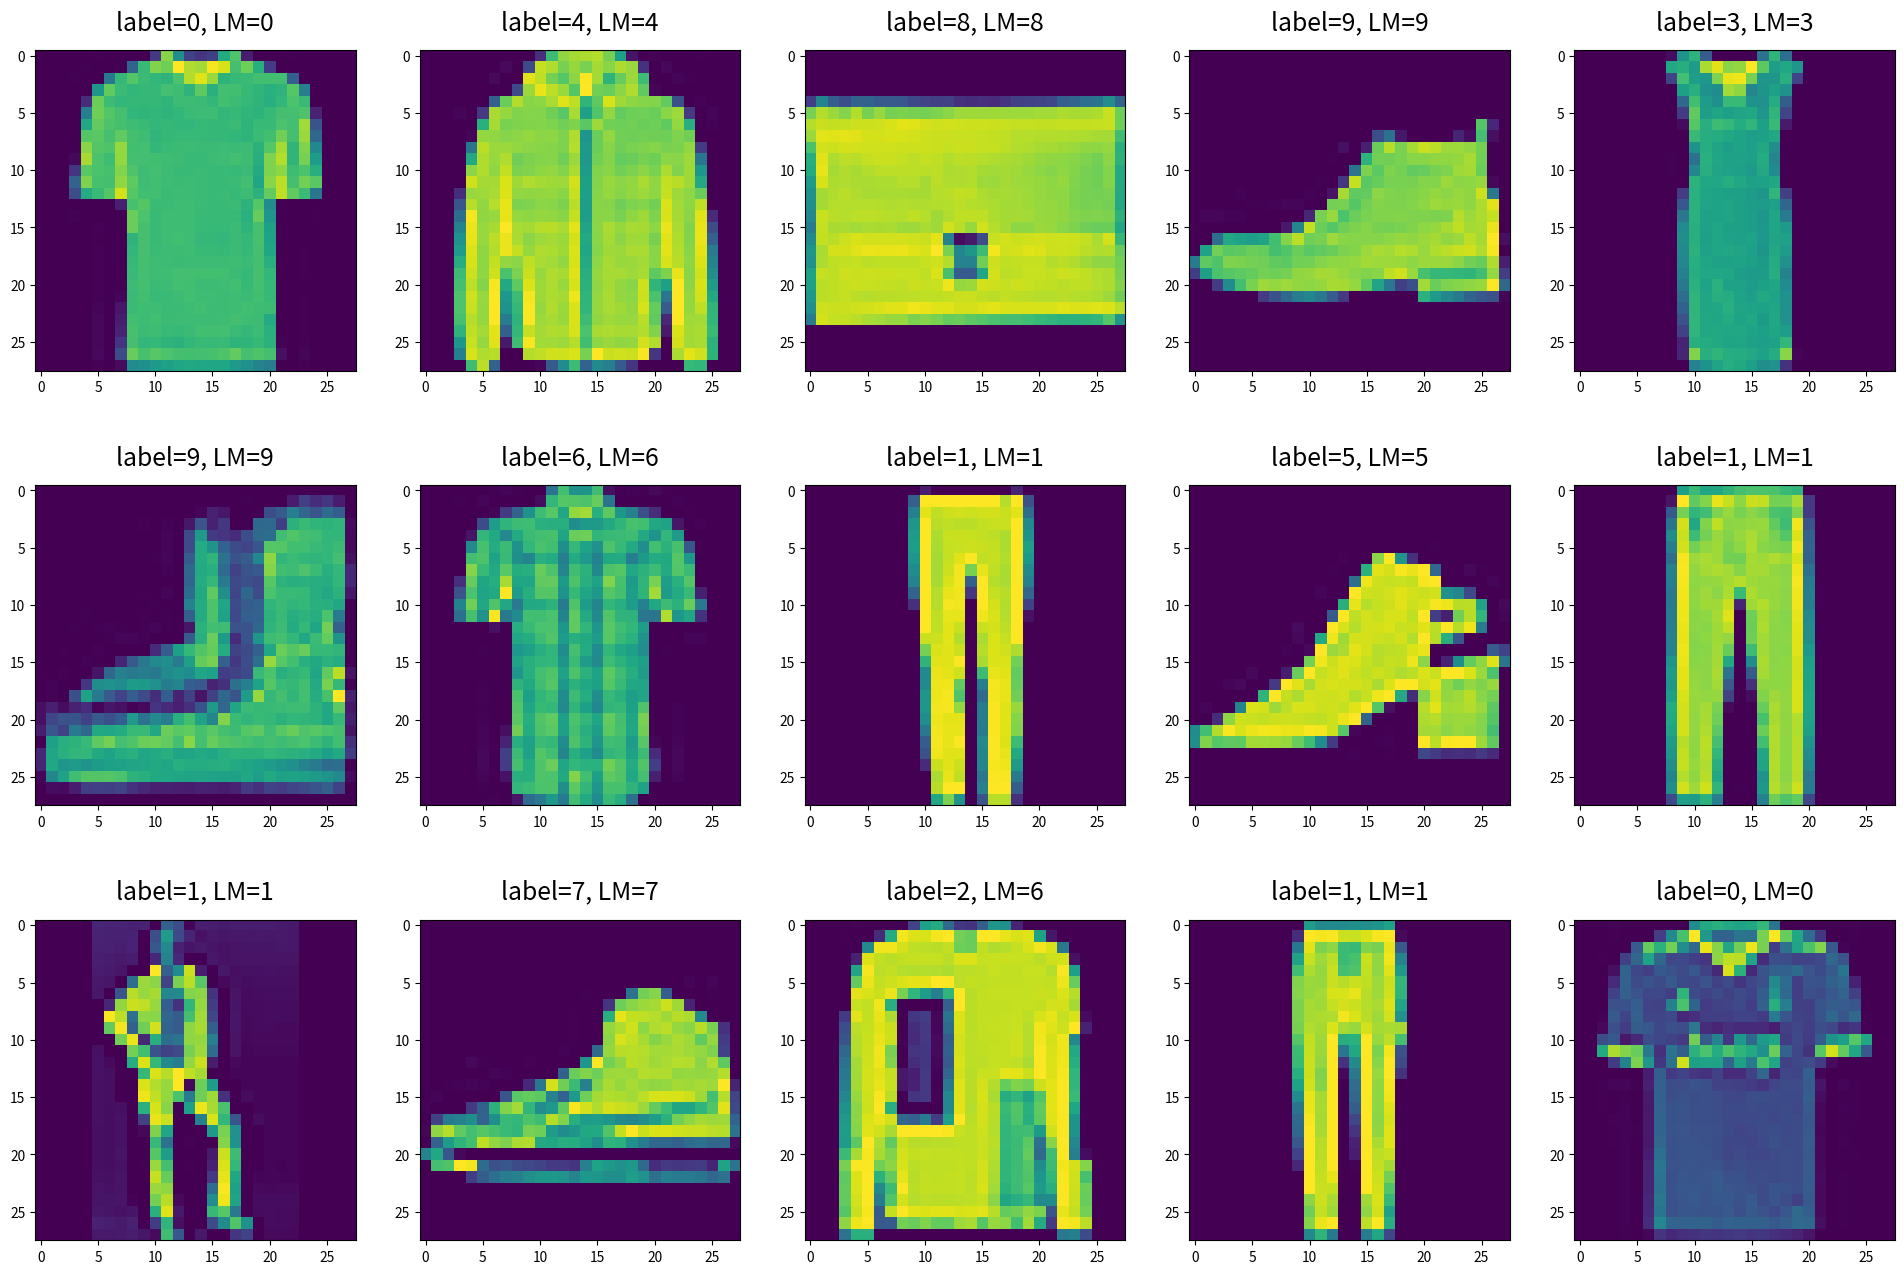

In [ ]:
row = 3
col = 5
fig, ax = plt.subplots(row, col, figsize=((col + 1) * 4, (row + 1) * 4), dpi=100)

size = row * col
length = len(y_test)

for i in range(0, size):
    k = np.random.randint(length)
    train = x_test[k]
    label = y_test[k]
    ax[i // col][i % col].imshow(train)
    ax[i // col][i % col].set_title("label=%d, LM=%d" % (label, pred_classes[k]))

plt.show()
plt.close()

#### 혼동행렬 시각화

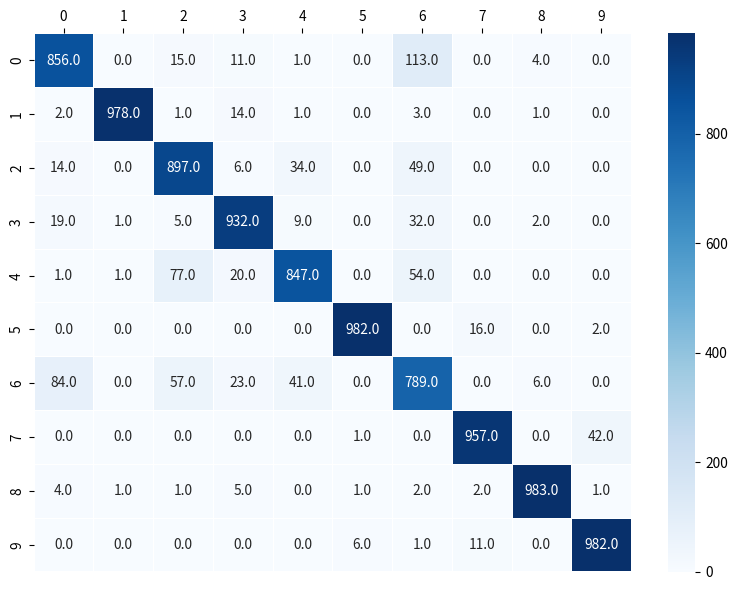

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_classes
)

figsize = (800 / 100, 600 / 100)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=100)

sb.heatmap(data=cm, annot=True, fmt="0.1f", linewidth=0.5, cmap="Blues")
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.tick_top()             # x축의 변수 이름을 상단으로 이동

plt.tight_layout()
plt.show()
plt.close()

## #05. 실제 제품 이미지 분류하기

#### (1) 이미지 불러오기

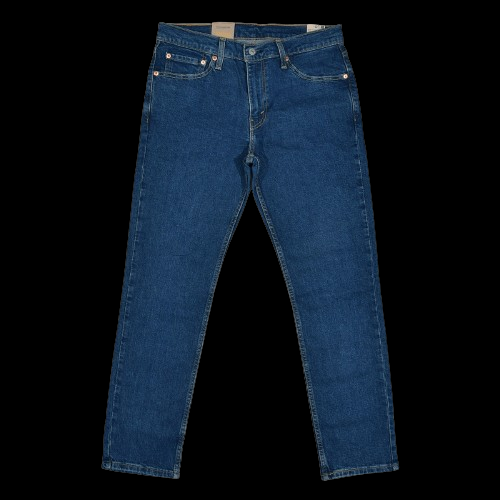

In [ ]:
img = Image.open("청바지.png")
img

#### (2) 이미지를 grayscale로 변환

일반 이미지는 R,G,B 세가지 색상의 조합으로 존재하기 때문에 (색상수x(가로크기x세로크기))의 3차원 데이터임

이미지를 grayscale(흑백이미지)로 변경하면 색상수가 1가지로 줄어들기 때문에 (가로크기x세로크기)의 2차원 데이터로 압축됨

In [ ]:
img_gray = img.convert(mode="L")

#### (3) 이미지 크기 축소

훈련모델이 학습한 이미지의 크기는 28x28이므로 이에 맞게 리사이즈가 필요

In [ ]:
resample = img_gray.resize([28, 28])
resample

#### (4) 이미지를 배열로 변환하기

In [ ]:
img_array = np.array(resample)

for i in img_array:
    for j in i:
        print("%03d" % j, end="")
    print()

000000000000000000000000000000000000000000000000000000000000000000000000000000000000
000000000000000000000000008040041053109050033033035067038006000000000000000000000000
000000000000000000000000018058055063085073072059052060058015000000000000000000000000
000000000000000000000000027056055071066055057052054050047031000000000000000000000000
000000000000000000000000047058059055051051057051056060056044001000000000000000000000
000000000000000000000002047055055051052057060049048050049049008000000000000000000000
000000000000000000000006046052051051052057056053056055052047011000000000000000000000
000000000000000000000009045051054055053057056053056052050046016000000000000000000000
000000000000000000000013050052055055055049050051055055052050024000000000000000000000
000000000000000000000020052054058058056045047054057056053052031000000000000000000000
000000000000000000000027053056058058058048047055057057056052035000000000000000000000
00000000000000000000003305405606005905703903305505705806005604200

#### (5) 이미지 색상 변경 (단색)

In [ ]:
청바지_array = np.where(img_array != 0, 128, img_array)

for i in 청바지_array:
    for j in i:
        print("%03d" % j, end="")
    print()

print(청바지_array.shape)

000000000000000000000000000000000000000000000000000000000000000000000000000000000000
000000000000000000000000128128128128128128128128128128128128000000000000000000000000
000000000000000000000000128128128128128128128128128128128128000000000000000000000000
000000000000000000000000128128128128128128128128128128128128000000000000000000000000
000000000000000000000000128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
000000000000000000000128128128128128128128128128128128128128128000000000000000000000
00000000000000000000012812812812812812812812812812812812812812812

#### (6) 독립변수 데이터 구성하기

In [ ]:
# 이미지를 배열로 묶음
myx = np.array(청바지_array)

# batch 차원 + channel 차원 추가
myx_reshape = myx.reshape(1, 28, 28, 1)

print(myx_reshape.shape)

(1, 28, 28, 1)


#### (7) 구성한 데이터를 학습모델에 적용

In [ ]:
myy = np.array([1])   # Trouser

result = model.predict(myx_reshape)

data_count, case_count = result.shape

print("%d개의 검증 데이터가 %d개의 경우의 수를 갖는다." % (data_count, case_count))

result[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1개의 검증 데이터가 10개의 경우의 수를 갖는다.


array([1.8378979e-04, 9.9674278e-01, 5.5001699e-05, 6.0575654e-05,
       1.8302124e-04, 1.7506797e-03, 7.1270892e-04, 2.9019057e-04,
       1.0512425e-05, 1.0771495e-05], dtype=float32)

#### (8) 산출된 값을 통해 판별 결과 생성

In [ ]:
arg_result = np.argmax(result, axis=-1)
arg_result

array([1])

#### (9) 결과 출력하기

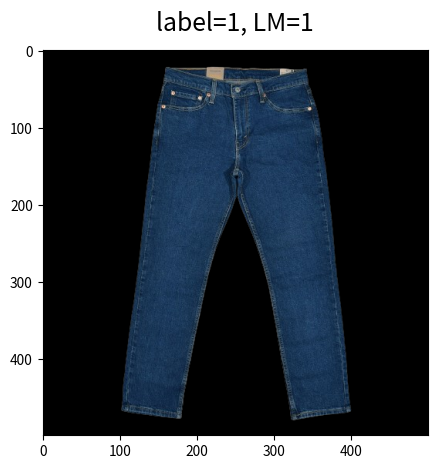

In [ ]:
col = 1

fig, ax = plt.subplots(1, col, figsize=(10, 5), dpi=100)

train = myx
label = myy[0]

ax.imshow(img)
ax.set_title("label=%d, LM=%d" % (label, arg_result[0]))

plt.show()
plt.close()